In [1]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

torch.set_default_dtype(torch.float64)

# f and g

PDE function and boundary function respectively

Example in section 4.2.1 of the paper:

In [2]:
"""
d = 2              # the input dimension
a, b = 0.0, 1.0    # the domain will be [a,b]^d

# Define the initial value
def f(x):
    return -2 * torch.ones(x.shape[0])

def g(x):
    return torch.where((x[:, 1] == a) | (x[:, 1] == b),
                       torch.where(x[:, 0] <= 1/2, x[:, 0]**2, (1-x[:, 0])**2),
                       0).unsqueeze(1)

def u_analytic(x):
    return torch.where(x[:, 0] <= 0.5, x[:, 0]**2, (1-x[:, 0])**2).unsqueeze(1)
"""

'\nd = 2              # the input dimension\na, b = 0.0, 1.0    # the domain will be [a,b]^d\n\n# Define the initial value\ndef f(x):\n    return -2 * torch.ones(x.shape[0])\n\ndef g(x):\n    return torch.where((x[:, 1] == a) | (x[:, 1] == b),\n                       torch.where(x[:, 0] <= 1/2, x[:, 0]**2, (1-x[:, 0])**2),\n                       0).unsqueeze(1)\n\ndef u_analytic(x):\n    return torch.where(x[:, 0] <= 0.5, x[:, 0]**2, (1-x[:, 0])**2).unsqueeze(1)\n'

Example in sec. 4.2.2 (works in any dimension):

In [3]:

d = 5                # the input dimension
a, b = 0.0, math.pi   # the domain will be [a,b]^d

# Define the initial value
def f(x):
    return x.sin().sum(axis=1, keepdim=True)

def g(x):
    return f(x)

def u_analytic(x):
    return f(x)


# Distance Function

In [4]:
def distance_to_boundary(x, a, b):
    """
    Computes the shortest distance from x to the boundary of [a, b]^d.
    Assumes x is inside the domain.
    """
    # 1. Distance to lower walls (x_i - a) and upper walls (b - x_i)
    #    shape: [batch_size, d]
    dist_to_walls = torch.minimum(x - a, b - x)

    # 2. The distance to the boundary is the minimum of these component distances
    #    shape: [batch_size, 1]
    #    Use .values to get the actual numbers from the min() result
    min_dist, _ = torch.min(dist_to_walls, dim=1, keepdim=True)

    return min_dist

def w(x):
    return distance_to_boundary(x, a, b)

# NN Architecture

In [5]:
# Define neural networks as in the paper,
# except for some confusion about N_adv

# Switch ELU to Softplus for second f, g pair
N_sol = torch.nn.Sequential(
    torch.nn.Linear(d, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Softplus(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 40), torch.nn.Softplus(),
    torch.nn.Linear(40, 40), torch.nn.Tanh(),
    torch.nn.Linear(40, 1)
)

N_adv = torch.nn.Sequential(
    torch.nn.Linear(d, 50), torch.nn.Tanh(),
    torch.nn.Linear(50, 50), torch.nn.Tanh(),
    torch.nn.Linear(50, 50), torch.nn.Softplus(),
    torch.nn.Linear(50, 50), torch.nn.Tanh(),
    torch.nn.Linear(50, 50), torch.nn.Softplus(),
    torch.nn.Linear(50, 50), torch.nn.Tanh(),
    torch.nn.Linear(50, 50), torch.nn.Tanh(),
    torch.nn.Linear(50, 50), torch.nn.Softplus(),
    torch.nn.Linear(50, 1)
)

# Training Parameters

Hyperparameters for example in 4.2.1:

In [6]:
"""
# Configure the training parameters and optimization algorithm
steps = 2000
batch_size_int = 256
batch_size_bdry = 2 * d * 25
alpha = 10000
lr_sol, lr_adv = 0.015, 0.04
steps_sol, steps_adv = 8, 4

optimizer_sol = torch.optim.Adagrad(N_sol.parameters(), lr=lr_sol)
optimizer_adv = torch.optim.Adagrad(N_adv.parameters(), lr=lr_adv, maximize=True)
"""

'\n# Configure the training parameters and optimization algorithm\nsteps = 2000\nbatch_size_int = 256\nbatch_size_bdry = 2 * d * 25\nalpha = 10000\nlr_sol, lr_adv = 0.015, 0.04\nsteps_sol, steps_adv = 8, 4\n\noptimizer_sol = torch.optim.Adagrad(N_sol.parameters(), lr=lr_sol)\noptimizer_adv = torch.optim.Adagrad(N_adv.parameters(), lr=lr_adv, maximize=True)\n'

Hyperparameters for example in 4.2.2:

In [7]:
# Configure the training parameters and optimization algorithm
steps = 8000 
batch_size_int = 256
batch_size_bdry = 2 * d * 30
alpha = 10000
lr_sol, lr_adv = 0.001, 0.015
steps_sol, steps_adv = 4, 4

optimizer_sol = torch.optim.Adam(N_sol.parameters(), lr=lr_sol)
optimizer_adv = torch.optim.Adagrad(N_adv.parameters(), lr=lr_adv)
                                    #maximize=True)

# Loss Function

In [8]:

def get_grad(y, x):
    """Computes the gradient of y with respect to x."""
    grad = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,  # Essential for training
        retain_graph=True,
        only_inputs=True
    )[0]
    return grad

def loss_weak(N_sol, N_adv, f_func, g_func, x_int, x_bdry, alpha):
    """
    Computes the WAN loss using the weak formulation.
    PDE: -Delta u = f
    Weak Form: Integral( grad(u) . grad(v) - f * v ) dx

    Args:
        N_sol:   The solution network u(x)
        N_adv:   The test function network v(x) (Adversary)
        f_func:  Function for source term f(x)
        g_func:  Function for boundary condition g(x)
        x_int:   Interior points (requires_grad=True)
        x_bdry:  Boundary points
        alpha:   Weight for boundary condition
    """

    # --- 1. Interior Residual (The Weak Form) ---
    # Ensure inputs track gradients for autograd
    x_int.requires_grad = True

    u = N_sol(x_int)
    v = w(x_int) * N_adv(x_int)

    # Compute gradients (du/dx and dv/dx)
    du = get_grad(u, x_int)
    dv = get_grad(v, x_int)

    # Source term f(x)
    f = f_func(x_int)

    # The Weak Form Integrand: (grad u . grad v) - f * v
    # Sum over dimensions (dot product), then average over batch (integral approx)
    # du * dv performs element-wise multiplication; sum(dim=1) is the dot product
    integrand = torch.sum(du * dv, dim=1, keepdim=True) - f * v

    # Monte Carlo integration over the domain volume V
    integral_val = torch.mean(integrand)

    # The Adversarial Objective for the interior
    # We want to minimize the operator norm
    # L_int = torch.log(torch.abs(integral_val)) - torch.log(torch.norm(v, p=2))
    L_int = torch.log(torch.square(integral_val)) - torch.log(torch.sum(torch.square(v)))
    #L_int = L_int.square() # Otherwise negative values interfere with L_bdry

    # --- 2. Boundary Condition ---
    u_bdry = N_sol(x_bdry)
    g_val = g_func(x_bdry)

    # Simple MSE on the boundary
    L_bdry = torch.mean(torch.square(u_bdry - g_val))

    # --- Total Loss ---
    # Solver wants to minimize this. Adversary wants to maximize the Interior part.
    return L_int + alpha * L_bdry

# Reduced function with boundary terms removed
def loss_weak_adv(N_sol, N_adv, f_func, x_int):
    """
    Computes the WAN loss using the weak formulation.
    PDE: -Delta u = f
    Weak Form: Integral( grad(u) . grad(v) - f * v ) dx

    Args:
        N_sol:   The solution network u(x)
        N_adv:   The test function network v(x) (Adversary)
        f_func:  Function for source term f(x)
        x_int:   Interior points (requires_grad=True)
    """

    # --- 1. Interior Residual (The Weak Form) ---
    # Ensure inputs track gradients for autograd
    x_int.requires_grad = True

    u = N_sol(x_int)
    v = w(x_int) * N_adv(x_int)

    # Compute gradients (du/dx and dv/dx)
    du = get_grad(u, x_int)
    dv = get_grad(v, x_int)

    # Source term f(x)
    f = f_func(x_int)

    # The Weak Form Integrand: (grad u . grad v) - f * v
    # Sum over dimensions (dot product), then average over batch (integral approx)
    # du * dv performs element-wise multiplication; sum(dim=1) is the dot product
    integrand = torch.sum(du * dv, dim=1, keepdim=True) - f * v

    # Monte Carlo integration over the domain volume V
    # Note: If domain is not [0,1]^d, scale by Volume.
    # For optimization, the constant scalar Volume doesn't change the minimum.
    integral_val = torch.mean(integrand)

    # The Adversarial Objective for the interior
    # We want to minimize the operator norm
    #L_int = torch.log(torch.abs(integral_val)) - torch.log(torch.norm(v, p=2))
    #L_int = L_int.square()
    L_int = torch.log(torch.square(integral_val)) - torch.log(torch.sum(torch.square(v)))

    # No boundary needed for training N_adv.

    # --- Total Loss ---
    # Adversary wants to maximize this.
    return L_int

# Training Loop

In [9]:
from tqdm import tqdm # For progress bar

# Train the network
pbar = tqdm(range(steps), desc='Training', unit='epochs')
for step in pbar:

    # --- Update Solver (Minimizing Loss) ---
    # 1. Freeze Adversary, Unfreeze Solver
    for p in N_adv.parameters(): p.requires_grad = False
    for p in N_sol.parameters(): p.requires_grad = True

    N_sol.train()
    N_adv.eval() # Optional depending on architecture, but good practice for consistency

    for _ in range(steps_sol):
        # Generate data inside the inner loop to prevent overfitting a single batch
        x_int = (torch.rand(batch_size_int, d) * (b - a) + a)

        # Generate boundary points: take random sample inside [a,b]^d and
        # snap random coordinate to a or b
        x_bdry = (torch.rand(batch_size_bdry, d) * (b - a) + a)
        indices = torch.randint(0, d, (batch_size_bdry,))
        x_bdry[torch.arange(batch_size_bdry), indices] = \
            a + (b - a) * torch.randint(0, 2, (batch_size_bdry,))

        optimizer_sol.zero_grad()

        # Calculate Loss
        L_sol = loss_weak(N_sol, N_adv, f, g, x_int, x_bdry, alpha)

        L_sol.backward()
        optimizer_sol.step()
    
    if step % 50 == 0:
        pbar.set_description_str(f'Training: Loss = {L_sol.item():.2e}')

    # --- Update Adversary (Maximizing Loss) ---
    # 1. Freeze Solver, Unfreeze Adversary
    for p in N_sol.parameters(): p.requires_grad = False
    for p in N_adv.parameters(): p.requires_grad = True

    N_sol.eval()
    N_adv.train() # CRITICAL: Switch Adv back to train mode

    for _ in range(steps_adv):
        # Generate fresh data for the adversary step as well
        x_int = (torch.rand(batch_size_int, d) * (b - a) + a)

        x_bdry = (torch.rand(batch_size_bdry, d) * (b - a) + a)
        indices = torch.randint(0, d, (batch_size_bdry,))
        x_bdry[torch.arange(batch_size_bdry), indices] = \
            a + (b - a) * torch.randint(0, 2, (batch_size_bdry,))

        optimizer_adv.zero_grad()

        # Negative loss for maximization
        L_adv = loss_weak_adv(N_sol, N_adv, f, x_int).negative()

        L_adv.backward()
        optimizer_adv.step()

Training: Loss = -2.99e+00: 100%|███████| 8000/8000 [07:57<00:00, 16.74epochs/s]


# PDE Error

In [10]:
# Keep PDE error outside of training for speed

n_samples = batch_size_int

def get_laplacian(u, x):
    """
    Computes the Laplacian of u with respect to x.
    Laplacian u = sum( d^2u / dx_i^2 )
    """
    # 1. First Derivative (Gradient)
    # du shape: [Batch_Size, d]
    du = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # 2. Divergence of the Gradient (Trace of the Hessian)
    # We must loop over dimensions d to get the diagonal elements of the Hessian
    # This is O(d) cost.
    laplacian = torch.zeros_like(u)
    d = x.shape[1]
    
    for i in range(d):
        # Extract the i-th component of the gradient
        du_i = du[:, i:i+1]
        
        # Take derivative of that component w.r.t x (second derivative)
        d2u_i = torch.autograd.grad(
            outputs=du_i,
            inputs=x,
            grad_outputs=torch.ones_like(du_i),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        
        # We only care about the i-th column (d^2u / dx_i^2)
        laplacian += d2u_i[:, i:i+1]
        
    return laplacian

for p in N_sol.parameters(): p.requires_grad = False
N_sol.eval()

x_int = (torch.rand(n_samples, d) * (b - a) + a)
x_int.requires_grad = True
u = N_sol(x_int)

pde_error = -get_laplacian(u, x_int) - f(x_int)

print(torch.mean(pde_error).detach().item())

-0.04513600382006762


# Numerical Comparisons

## Boundary Error

In [11]:
# Compute bdry error
n_samples = 100 * batch_size_bdry

N_sol.eval() # Switch to evaluation mode

with torch.no_grad(): # Disable gradient calculation for testing
    # 1. Generate boundary samples
    x_bdry = (torch.rand(n_samples, d) * (b - a) + a)
    indices = torch.randint(0, d, (n_samples,))
    x_bdry[torch.arange(n_samples), indices] = \
        a + (b - a) * torch.randint(0, 2, (n_samples,))

    # 2. Get predictions and exact values
    u_pred = N_sol(x_bdry)
    u_true = u_analytic(x_bdry)

    # Ensure shapes match (e.g., both are [N, 1])
    if u_pred.shape != u_true.shape:
        u_true = u_true.reshape(u_pred.shape)

    # 3. Compute Errors
    # Absolute difference vector
    diff = u_pred - u_true

    # L2 Relative Error: ||u_pred - u_true||_2 / ||u_true||_2
    l2_error = torch.norm(diff, p=2) / (torch.norm(u_true, p=2))

print(f"Relative L2 Error: {l2_error.item():.6e}")

Relative L2 Error: 9.431133e-03


## Interior Error

In [12]:
# Compute bdry error
n_samples = 100 * batch_size_int

N_sol.eval() # Switch to evaluation mode

with torch.no_grad(): # Disable gradient calculation for testing
    # 1. Generate boundary samples
    x_int = (torch.rand(batch_size_int, d) * (b - a) + a)

    # 2. Get predictions and exact values
    u_pred = N_sol(x_int)
    u_true = u_analytic(x_int)

    # Ensure shapes match (e.g., both are [N, 1])
    if u_pred.shape != u_true.shape:
        u_true = u_true.reshape(u_pred.shape)

    # 3. Compute Errors
    # Absolute difference vector
    diff = u_pred - u_true

    # L2 Relative Error: ||u_pred - u_true||_2 / ||u_true||_2
    l2_error = torch.norm(diff, p=2) / (torch.norm(u_true, p=2))

print(f"Relative L2 Error: {l2_error.item():.6e}")

Relative L2 Error: 2.202339e-02


# Plot

## 3D Plot

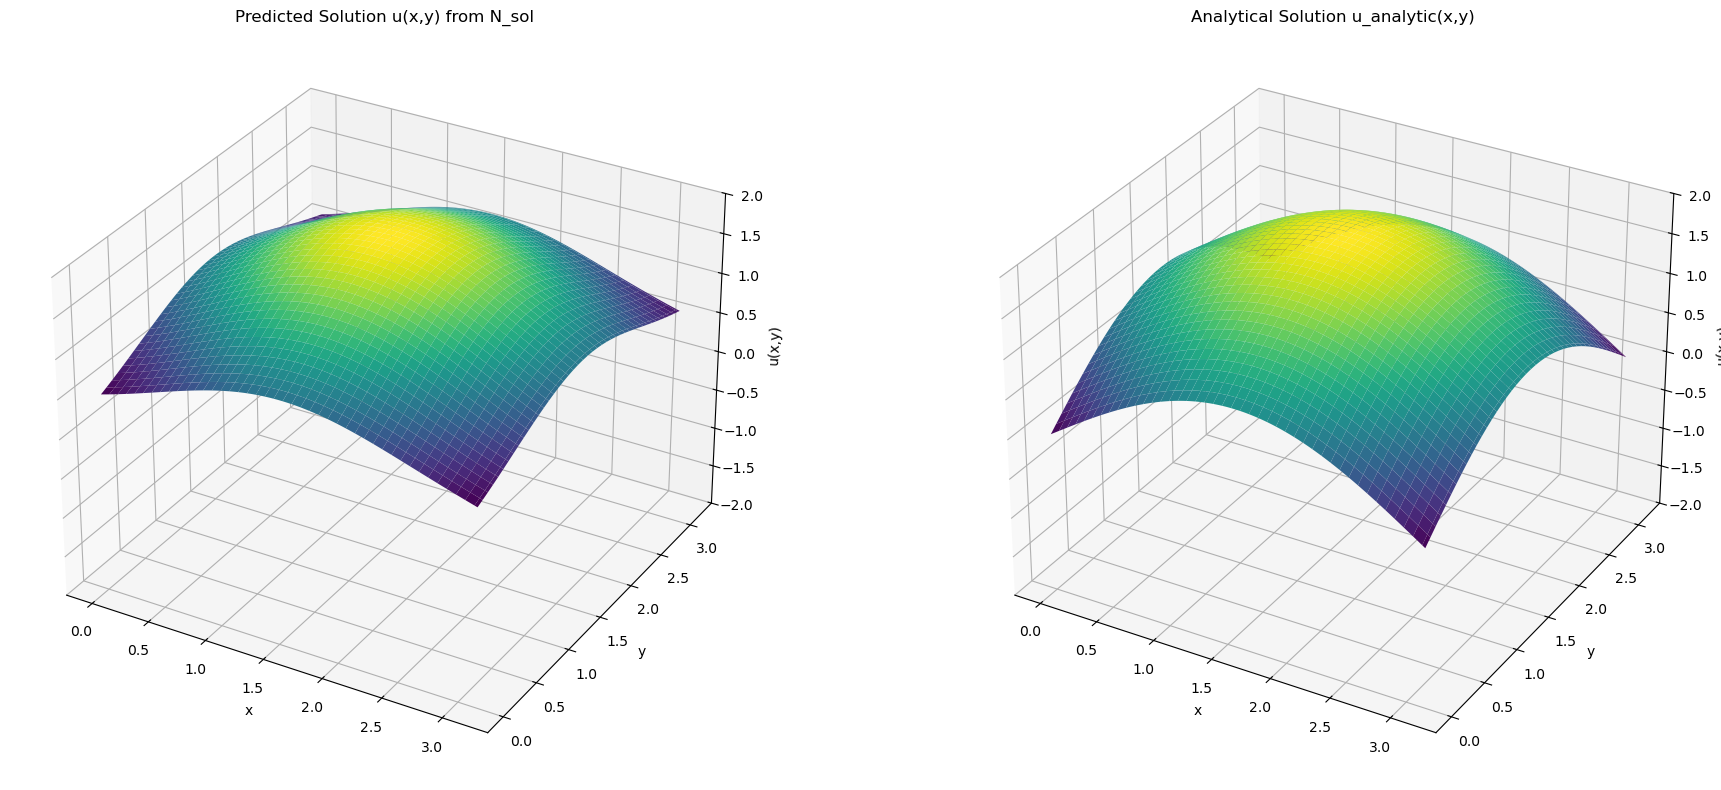

In [13]:
# Plot the predicted solution from N_sol against the exact solution
mesh = 128

def toNumpy(t):
    return t.detach().cpu().numpy().reshape((mesh,mesh))

# Create a figure with two subplots
fig = plt.figure(figsize=(20, 8)) # Wider figure to accommodate two plots

# Generate meshgrid for the domain
x = torch.linspace(a, b, mesh)
y = torch.linspace(a, b, mesh)
X, Y = torch.meshgrid(x, y, indexing='xy')

# Prepare input for N_sol:
# Chose the first two coordinates from a mesh and set the rest to a=0
# (needs rework): a * torch.ones((coords.shape[0], d-2))
coords = torch.cat((X.reshape(-1, 1), Y.reshape(-1, 1)), 1)
coords = torch.cat((coords, torch.zeros((coords.shape[0], d-2))), 1)

N_sol.eval() # Ensure N_sol is in evaluation mode
with torch.no_grad(): # Disable gradient calculation
    Z_pred_N_sol = N_sol(coords)

Z_analytic = u_analytic(coords)

Z_pred_N_sol_np = toNumpy(Z_pred_N_sol.flatten()) # Flatten and reshape for plotting
Z_analytic_np = toNumpy(Z_analytic.flatten()) # Flatten and reshape for plotting

# --- First Subplot: Predicted Solution from N_sol ---
ax1 = fig.add_subplot(121, projection='3d') # 1 row, 2 columns, 1st plot
ax1.plot_surface(toNumpy(X), toNumpy(Y), Z_pred_N_sol_np,
                cmap='viridis')

ax1.set_title("Predicted Solution u(x,y) from N_sol")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("u(x,y)")
ax1.set_zlim(-2, 2) # Set z-axis limits for better visualization

# --- Second Subplot: Analytical Solution ---
ax2 = fig.add_subplot(122, projection='3d') # 1 row, 2 columns, 2nd plot
ax2.plot_surface(toNumpy(X), toNumpy(Y), Z_analytic_np,
                cmap='viridis')

ax2.set_title("Analytical Solution u_analytic(x,y)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("u(x,y)")
ax2.set_zlim(-2, 2) # Set z-axis limits for better visualization

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

## Plot Diagonal Values


In [14]:
num_points = 1000
diagonal_coords = torch.linspace(a, b, num_points)
diagonal_points = diagonal_coords.unsqueeze(1).repeat(1, d)

N_sol.eval()

with torch.no_grad():
    predicted_values_diagonal = N_sol(diagonal_points)

true_values_diagonal = u_analytic(diagonal_points)

# Display some values for sanity check
print("Shape of predicted_values_diagonal:", predicted_values_diagonal.shape)
print("First 5 predicted values:\n", predicted_values_diagonal[:5])

print("Shape of true_values_diagonal:", true_values_diagonal.shape)
print("First 5 true values:\n", true_values_diagonal[:5])

Shape of predicted_values_diagonal: torch.Size([1000, 1])
First 5 predicted values:
 tensor([[0.4997],
        [0.5067],
        [0.5138],
        [0.5209],
        [0.5280]])
Shape of true_values_diagonal: torch.Size([1000, 1])
First 5 true values:
 tensor([[0.0000],
        [0.0157],
        [0.0314],
        [0.0472],
        [0.0629]])


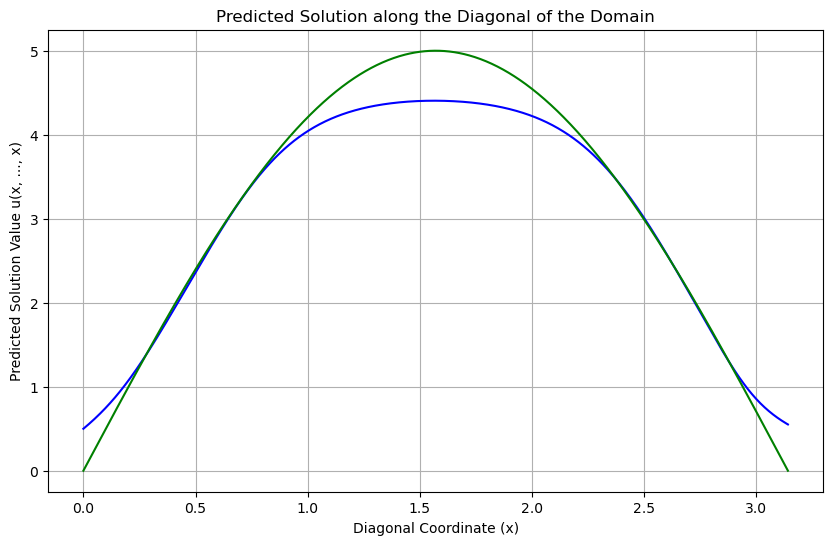

In [15]:
import matplotlib.pyplot as plt

# Convert tensors to NumPy arrays and flatten predicted_values_diagonal
diagonal_coords_np = diagonal_coords.cpu().numpy()
predicted_values_diagonal_np = predicted_values_diagonal.cpu().numpy().flatten()

# Create the 2D plot
plt.figure(figsize=(10, 6))
plt.plot(diagonal_coords_np, predicted_values_diagonal_np, color='blue')
plt.plot(diagonal_coords_np, true_values_diagonal, color='green')

# Add labels and title
plt.xlabel("Diagonal Coordinate (x)")
plt.ylabel("Predicted Solution Value u(x, ..., x)")
plt.title("Predicted Solution along the Diagonal of the Domain")
plt.grid(True)

# Display the plot
plt.show()